# **PART A**

#1)
1. What is Data Analysis?

Data analysis is the structured process of inspecting, cleaning, transforming, and modeling data to uncover useful information and support decision-making. This process involves a clear sequence of steps, beginning with collecting raw data and cleaning it to remove errors or missing values. Next, data scientists explore and visualize the data to understand underlying patterns and trends. Finally, they perform feature engineering to refine the variables, build statistical or predictive models, and rigorously evaluate those models to ensure their accuracy and reliability.

2. How to Plan a Data Science Project

Planning a data science project requires a comprehensive lifecycle that bridges business goals with technical execution. The first and most crucial phase is business understanding, where the core problem and objectives are clearly defined. Following this, relevant data is collected from multiple sources and meticulously prepared by handling outliers, duplicates, and missing values. The process then moves through exploratory data analysis to discover relationships in the data, feature engineering to create meaningful inputs, and model building using appropriate machine learning algorithms. The project concludes with evaluating the model's performance metrics and deploying it into a real-world environment for practical, everyday use.

3. How to Frame a Machine Learning Problem

Framing a machine learning problem involves translating a specific business challenge into a structured technical task by identifying the learning type and the exact target to be predicted. For example, if a financial institution's objective is to predict whether a customer will default on a loan, the problem is framed as a supervised learning task. In this scenario, the algorithm must learn from historical data to classify future outcomes, and the specific target variable it aims to predict would be a distinct indicator, such as a "default_flag."


### 2)**explain tensors and provide an in depth explanation with numpy example**

* **Definition:** A tensor is a mathematical container for numerical data. It generalizes the concepts of scalars, vectors, and matrices to an arbitrary number of dimensions, making it the fundamental data structure in machine learning.
* **Dimensionality (Rank/Order):** The number of dimensions a tensor has is called its rank.
* **Rank 0 (Scalar):** A single number with zero dimensions (e.g., `42`).
* **Rank 1 (Vector):** A 1D array of numbers (e.g., `[1, 2, 3]`).
* **Rank 2 (Matrix):** A 2D grid of numbers arranged in rows and columns.
* **Rank 3+ (N-Dimensional Tensor):** A 3D cube of numbers (like a color image with height, width, and RGB channels) or higher-dimensional structures.


* **NumPy Implementation:** In Python, tensors are created and manipulated using NumPy's `ndarray` (N-dimensional array) object.
* **Key Properties:**
* **`.ndim`:** Returns the tensor's rank (the total number of axes).
* **`.shape`:** Returns a tuple showing the exact size of the tensor along each dimension (e.g., a matrix with 3 rows and 4 columns has a shape of `(3, 4)`).

# **PART B**

In [43]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

In [44]:
df = pd.read_csv("/content/bank_loan_dataset_1000_rows.csv")
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST100000,59.0,Male,East,Secondary,Unemployed,513336.46,37038.53,Home,664.5,3,229,99.66,2020-10-11,0
1,CUST100001,49.0,Female,North,Graduate,NaN,955398.86,131678.27,Business,595.7,0,97,20.04,2022-01-08,1
2,CUST100002,35.0,Male,East,Graduate,Salaried,NaN,82686.98,Other,701.6,0,185,34.35,2024-01-06,0
3,CUST100003,63.0,Female,North,Secondary,Self-Employed,503905.42,84807.48,Business,607.3,3,178,29.80,2018-01-10,0
4,CUST100004,28.0,Male,East,Secondary,Salaried,NaN,39114.18,Business,686.5,2,358,27.23,2022-04-15,0


# Part C: Data Understanding & Cleaning

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   object 
 1   age                950 non-null    float64
 2   gender             951 non-null    object 
 3   region             1000 non-null   object 
 4   education_level    1000 non-null   object 
 5   employment_type    955 non-null    object 
 6   annual_income      960 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   object 
 9   credit_score       965 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   object 
 14  default_flag       1000 non-null   int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 117.3+ KB


In [46]:
df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,950.000000,9.600000e+02,1.000000e+03,965.000000,1000.000,1000.000000,1000.000000,1000.00000
mean,45.721053,5.648155e+05,9.960277e+04,680.611192,1.969,253.679000,37.381960,0.13200
std,14.398699,6.472496e+05,9.946454e+04,90.614953,1.400,142.234675,23.420178,0.33866
min,21.000000,7.114268e+04,8.560210e+03,397.300000,0.000,5.000000,0.680000,0.00000
25%,33.000000,2.974969e+05,4.695492e+04,618.500000,1.000,136.000000,19.957500,0.00000
50%,46.000000,4.387677e+05,7.365190e+04,684.100000,2.000,253.500000,32.300000,0.00000
75%,57.000000,6.598466e+05,1.202544e+05,745.500000,3.000,381.000000,48.902500,0.00000
max,70.000000,1.217144e+07,1.350869e+06,850.000000,7.000,499.000000,142.320000,1.00000


In [47]:
df.shape


(1000, 15)

In [48]:
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'education_level',
       'employment_type', 'annual_income', 'loan_amount', 'loan_purpose',
       'credit_score', 'repayment_history', 'transaction_count',
       'spending_ratio', 'join_date', 'default_flag'],
      dtype='object')

In [49]:
df.isnull().sum()

,0
customer_id,0
age,50
gender,49
region,0
education_level,0
employment_type,45
annual_income,40
loan_amount,0
loan_purpose,0
credit_score,35


# Missing Value Visualization

<Axes: >

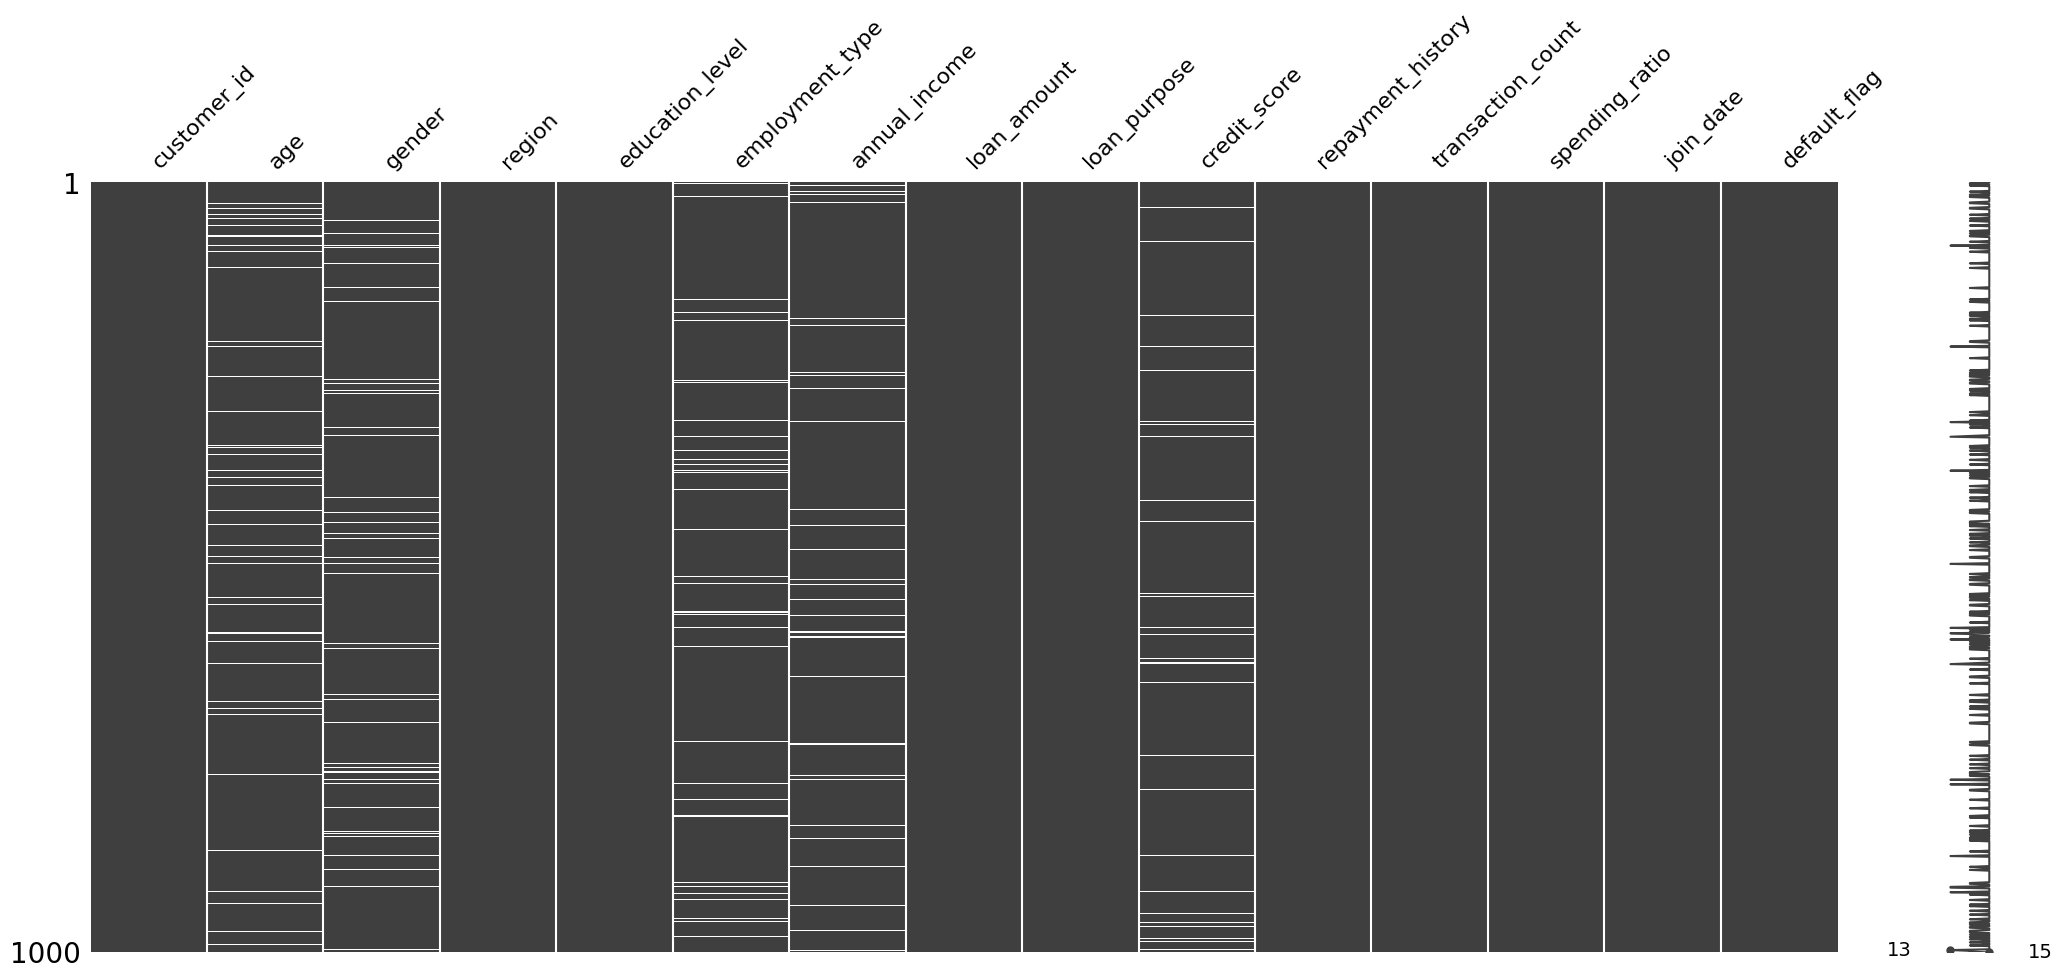

In [50]:
import missingno as msno

msno.matrix(df)

In [51]:
df_mean = df.copy()

df_mean["age"] = df_mean["age"].fillna(
    df_mean["age"].mean()
)

In [52]:
df_median = df.copy()

df_median["credit_score"] = df_median["credit_score"].fillna(
    df_median["credit_score"].median()
)

In [53]:
df["employment_type"] = df["employment_type"].fillna(
    df["employment_type"].mode()[0]
)

In [54]:
df["income_missing"] = df["annual_income"].isnull().astype(int)

In [55]:
df["age"] = df["age"].fillna(
    df["age"].mode()[0]
)

In [56]:
df["gender"] = df["gender"].fillna(
    df["gender"].mode()[0]
)

In [62]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
region,0
education_level,0
employment_type,0
annual_income,0
loan_amount,0
loan_purpose,0
credit_score,0


# Random Sample Imputation

In [57]:
random_sample = df["annual_income"].dropna()

df.loc[
    df["annual_income"].isnull(),
    "annual_income"
] = np.random.choice(
    random_sample,
    size=df["annual_income"].isnull().sum()
)

# KNN Imputer

In [58]:
from sklearn.impute import KNNImputer
knn_cols = [
    "annual_income",
    "loan_amount",
    "credit_score"
]

imputer = KNNImputer(n_neighbors=5)

df[knn_cols] = imputer.fit_transform(
    df[knn_cols]
)

# MICE

In [59]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
mice = IterativeImputer(
    random_state=42
)
df[knn_cols] = mice.fit_transform(
    df[knn_cols]
)

# **Part D: Outlier Handling**

**Z Score Method**

In [63]:
from scipy.stats import zscore
z = np.abs(zscore(df["annual_income"]))
outliers = df[z > 3]

In [64]:
Q1 = df["loan_amount"].quantile(0.25)
Q3 = df["loan_amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["loan_amount"] < lower) |
    (df["loan_amount"] > upper)
]

In [66]:
lower = df["credit_score"].quantile(0.01)
upper = df["credit_score"].quantile(0.99)

df["credit_score"] = np.clip(
    df["credit_score"],
    lower,
    upper
)

**Winsorization**

In [67]:
from scipy.stats.mstats import winsorize

df["annual_income"] = winsorize(
    df["annual_income"],
    limits=[0.01,0.01]
)

# **Part E: Feature Engineering**

In [69]:
df["join_date"] = pd.to_datetime(
    df["join_date"]
)

df["join_year"] = df["join_date"].dt.year
df["join_month"] = df["join_date"].dt.month
df["join_day"] = df["join_date"].dt.day
df["join_weekday"] = df["join_date"].dt.weekday

In [71]:
education_map = {
    "Primary":1,
    "Secondary":2,
    "Graduate":3,
    "Post-Graduate":4
}

df["education_encoded"] = (
    df["education_level"]
    .map(education_map)
)

In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender_encoded"] = le.fit_transform(
    df["gender"]
)

In [73]:
df = pd.get_dummies(
    df,
    columns=[
        "region",
        "loan_purpose"
    ],
    drop_first=True
)

Binarization

In [75]:
df["income_bin"] = pd.cut(
    df["annual_income"],
    bins=5,
    labels=False
)

Quantile Binning

In [77]:
df["transaction_quantile"] = pd.qcut(
    df["transaction_count"],
    q=4,
    labels=False
)

KMeans Binning

In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["transaction_cluster"] = (
    kmeans.fit_predict(
        df[["transaction_count"]]
    )
)

# **Part F: Feature Scaling**

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["income_standard"] = scaler.fit_transform(
    df[["annual_income"]]
)

In [80]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

df["income_minmax"] = mms.fit_transform(
    df[["annual_income"]]
)

In [81]:
from sklearn.preprocessing import MaxAbsScaler

maxabs = MaxAbsScaler()

df["income_maxabs"] = maxabs.fit_transform(
    df[["annual_income"]]
)

# **Part G: Feature Construction & Transformation**

In [82]:
df["debt_to_income"] = (
    df["loan_amount"] /
    (df["annual_income"] + 1)
)

In [83]:
df["avg_monthly_transactions"] = (
    df["transaction_count"] / 6
)

In [85]:
df["spending_income_ratio"] = (
    df["spending_ratio"] /
    (df["annual_income"] + 1)
)

Log Transform

In [87]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(
    np.log1p
)
df["loan_log"] = log_transformer.fit_transform(
    df[["loan_amount"]]
)

Square Root Transform

In [89]:
df["loan_sqrt"] = np.sqrt(
    df["loan_amount"]
)

Reciprocal Transform

In [90]:
df["loan_reciprocal"] = (
    1 /
    (df["loan_amount"] + 1)
)

Box Cox

In [91]:
from sklearn.preprocessing import PowerTransformer

boxcox = PowerTransformer(
    method="box-cox"
)

df["income_boxcox"] = boxcox.fit_transform(
    df[["annual_income"]]
)

In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

numeric_features = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score"
]

categorical_features = [
    "gender",
    "employment_type"
]

numeric_transformer = Pipeline([
    ("imputer",
     SimpleImputer(strategy="median")),
    ("scaler",
     StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer",
     SimpleImputer(strategy="most_frequent")),
    ("onehot",
     OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",
     numeric_transformer,
     numeric_features),

    ("cat",
     categorical_transformer,
     categorical_features)
])

# **Final Dataset**

In [93]:
final_df = df.copy()

final_df.drop(
    columns=[
        "customer_id",
        "join_date"
    ],
    inplace=True
)
final_df.head()

,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,...,income_standard,income_minmax,income_maxabs,debt_to_income,avg_monthly_transactions,spending_income_ratio,loan_log,loan_sqrt,loan_reciprocal,income_boxcox
0,59.0,Male,Secondary,Unemployed,513336.46,37038.53,664.5,3,229,99.66,...,-0.059315,0.163730,0.204084,0.072152,38.166667,0.000194,10.519741,192.453969,0.000027,0.289254
1,49.0,Female,Graduate,Salaried,955398.86,131678.27,595.7,0,97,20.04,...,1.073699,0.348389,0.379832,0.137825,16.166667,0.000021,11.788124,362.875006,0.000008,1.258211
2,35.0,Male,Graduate,Salaried,508690.13,82686.98,701.6,0,185,34.35,...,-0.071224,0.161789,0.202237,0.162548,30.833333,0.000068,11.322830,287.553439,0.000012,0.274397
3,63.0,Female,Secondary,Self-Employed,503905.42,84807.48,607.3,3,178,29.80,...,-0.083487,0.159790,0.200334,0.168300,29.666667,0.000059,11.348151,291.217239,0.000012,0.258934
4,28.0,Male,Secondary,Salaried,393283.94,39114.18,686.5,2,358,27.23,...,-0.367012,0.113582,0.156355,0.099455,59.666667,0.000069,10.574266,197.773052,0.000026,-0.154477


In [94]:
df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag,income_missing,...,income_standard,income_minmax,income_maxabs,debt_to_income,avg_monthly_transactions,spending_income_ratio,loan_log,loan_sqrt,loan_reciprocal,income_boxcox
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000,1000.000000,1000.000000,1000,1000.00000,1000.000000,...,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,45.835000,5.364792e+05,9.960277e+04,680.987134,1.969,253.679000,37.381960,2021-10-19 03:57:36,0.13200,0.040000,...,-9.681145e-17,0.173397,0.213285,0.263335,42.279833,0.000099,11.233414,293.736449,1.692294e-05,4.640732e-16
min,21.000000,1.213756e+05,8.560210e+03,461.599390,0.000,5.000000,0.680000,2018-01-06 00:00:00,0.00000,0.000000,...,-1.063918e+00,0.000000,0.048255,0.003403,0.833333,0.000003,9.054997,92.521403,7.402638e-07,-2.336762e+00
25%,34.000000,2.976904e+05,4.695492e+04,619.375000,1.000,136.000000,19.957500,2020-01-22 12:00:00,0.00000,0.000000,...,-6.120202e-01,0.073650,0.118351,0.094361,22.666667,0.000038,10.756963,216.690780,8.315645e-06,-6.374912e-01
50%,47.000000,4.388545e+05,7.365190e+04,684.200000,2.000,253.500000,32.300000,2021-11-19 12:00:00,0.00000,0.000000,...,-2.502140e-01,0.132617,0.174473,0.174271,42.250000,0.000069,11.207118,271.388794,1.357721e-05,3.026856e-02
75%,57.000000,6.598466e+05,1.202544e+05,743.750000,3.000,381.000000,48.902500,2023-07-29 06:00:00,0.00000,0.000000,...,3.161930e-01,0.224930,0.262331,0.310429,63.500000,0.000130,11.697372,346.777065,2.129662e-05,6.916846e-01
max,70.000000,2.515321e+06,1.350869e+06,850.000000,7.000,499.000000,142.320000,2025-05-18 00:00:00,1.00000,1.000000,...,5.071811e+00,1.000000,1.000000,4.353261,83.166667,0.000651,14.116259,1162.268781,1.168059e-04,2.600690e+00
std,14.042541,3.903601e+05,9.946454e+04,88.398741,1.400,142.234675,23.420178,NaN,0.33866,0.196057,...,1.000500e+00,0.163061,0.155193,0.326434,23.705779,0.000089,0.715934,115.477276,1.305417e-05,1.000500e+00


# **Final Report Summary**

**Missing Values**

| Method        | Columns                                  |
| ------------- | ---------------------------------------- |
| Mean          | age                                      |
| Median        | credit_score                             |
| Mode          | employment_type                          |
| Random Sample | annual_income                            |
| KNN/MICE      | annual_income, loan_amount, credit_score |


**Outlier Handling**

| Method        | Column        |
| ------------- | ------------- |
| Z-score       | annual_income |
| IQR           | loan_amount   |
| Percentile    | credit_score  |
| Winsorization | annual_income |


**Encoding**

| Type    | Column               |
| ------- | -------------------- |
| Ordinal | education_level      |
| Label   | gender               |
| One-Hot | region, loan_purpose |


# ***New Features***


*   debt_to_income
*   avg_monthly_transactions


*   spending_income_ratio
*   join_year


*   join_month
*   join_day



*   join_weekday
